In [1]:
import pandas as pd
import sqlite3 
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

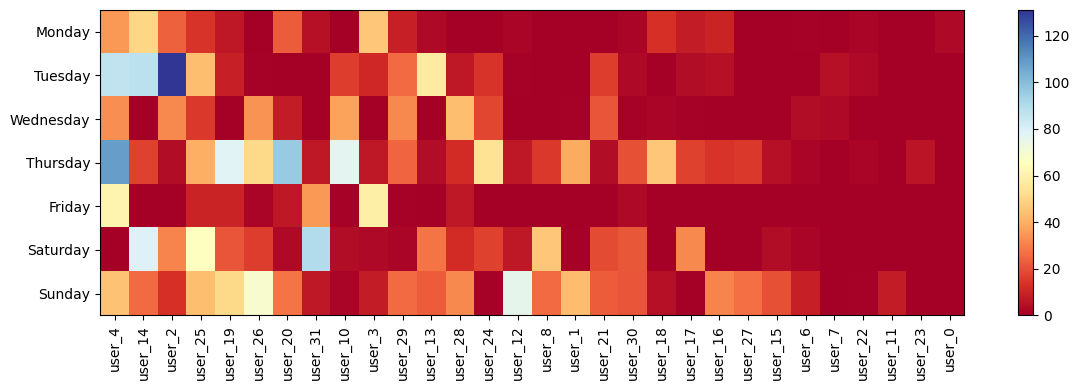

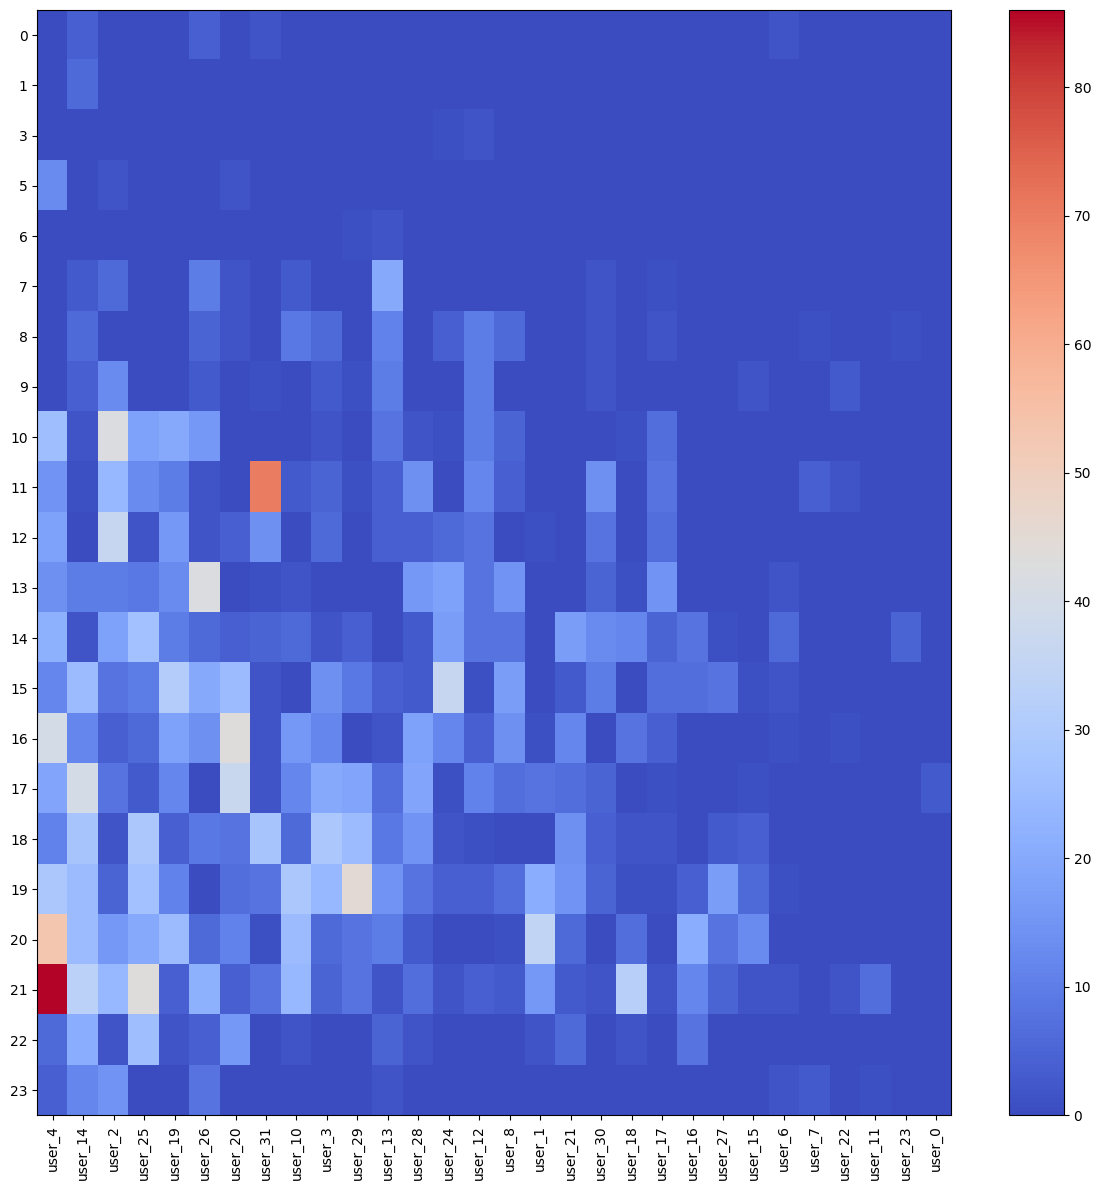

In [3]:
query = '''
SELECT
    *
FROM 
    checker
WHERE 
    uid LIKE 'user%'
'''


# First Graph
df = pd.read_sql_query(query, conn)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['day_name'] = df['timestamp'].dt.day_name()
df = df.groupby(['uid', 'day_name']).count().reset_index()[['uid', 'day_name', 'index']]

pivot_table = df.pivot(index='day_name', columns='uid', values='index')
pivot_table = pivot_table.fillna(0)
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot_table = pivot_table.reindex(days_order)
# Сортировка uid по сумме значений в сводной таблице (по столбцам) в порядке убывания
uid_order = pivot_table.sum(axis=0).sort_values(ascending=False).index
# Перестановка столбцов в сводной таблице в соответствии с отсортированным порядком uid
pivot_table = pivot_table[uid_order]
plt.figure(figsize=(12, 4))
heatmap = plt.imshow(pivot_table, cmap='RdYlBu', aspect='auto')
plt.colorbar(heatmap)
plt.xticks(range(len(pivot_table.columns)), pivot_table.columns, rotation=90)
plt.yticks(range(len(pivot_table.index)), pivot_table.index)
plt.tight_layout()
plt.show()

# Second Graph
df_days = pd.read_sql_query(query, conn)
df_days['timestamp'] = pd.to_datetime(df_days['timestamp'])
df_days['hour'] = df_days['timestamp'].dt.hour
df_days = df_days.groupby(['uid', 'hour']).count().reset_index()[['uid', 'hour', 'index']]

pivot_table2 = df_days.pivot(index='hour', columns='uid', values='index')
pivot_table2 = pivot_table2.fillna(0)
uid_order2 = pivot_table2.sum(axis=0).sort_values(ascending=False).index
pivot_table2 = pivot_table2[uid_order2]

plt.figure(figsize=(12, 12))
heatmap = plt.imshow(pivot_table2, cmap='coolwarm', aspect='auto')
plt.colorbar(heatmap)
plt.xticks(range(len(pivot_table2.columns)), pivot_table2.columns, rotation=90)
plt.yticks(range(len(pivot_table2.index)), pivot_table2.index)
plt.tight_layout()
plt.show()

In [4]:
conn.close()

## 1. User_2
## 2. User_4
## 3. Friday
## 4. User_4, 21 